# 🌊 วิเคราะห์ภัยพิบัติเกษตรและการช่วยเหลือเกษตรกร
## กรมส่งเสริมการเกษตร — EDA สำหรับเจ้าหน้าที่หน่วยงานภาครัฐ

---

### 📋 Dataset ที่ใช้ในการวิเคราะห์

| Dataset | ไฟล์ | ขนาด | ขอบเขต |
|---------|------|------|--------|
| **A** | `การช่วยเหลือผู้ประสบภัยพิบัติด้านการเกษตร.csv` | 419 rows | ทั่วประเทศ (ระดับตำบล) |
| **B** | `พื้นที่ปลูกข้าวที่ได้รับความเสียหายจากภัยธรรมชาติ.csv` | 57 rows | จ.อำนาจเจริญ |
| **C** | `พื้นที่เกษตรกรรมที่ได้รับความเสียหายจากภาวะฝนทิ้งช่วง.csv` | 16 rows | จ.เพชรบูรณ์ |
| **D** | `มูลค่าความเสียหายทางการเกษตรที่เกิดจากภาวะฝนทิ้งช่วง.csv` | 16 rows | จ.เพชรบูรณ์ |
| **E** | `การให้ความช่วยเหลือเกษตรกรผู้ประสบอุทกภัยด้านพืช.csv` | 12 rows | จ.สุราษฎร์ธานี |

### 🗺️ หัวข้อการวิเคราะห์
1. **แผนที่เหตุการณ์ภัยพิบัติและการช่วยเหลือเกษตรกร** (Dataset A - ทั่วประเทศ)
2. **วิเคราะห์ความเสียหายพืชผล จ.อำนาจเจริญ ปี 2565–2568** (Dataset B)
3. **ผลกระทบภาวะฝนทิ้งช่วงต่อเกษตรกร จ.เพชรบูรณ์** (Dataset C+D)
4. **ประสิทธิภาพการช่วยเหลืออุทกภัยด้านพืช จ.สุราษฎร์ธานี** (Dataset E)

---
## Section 0: Setup & Import 📦
ติดตั้ง library ที่จำเป็นและ import ทุกอย่าง

In [29]:
# ติดตั้ง library (รันครั้งแรกเท่านั้น)
# !pip install pandas matplotlib seaborn plotly folium geopy openpyxl

In [30]:
from tqdm import tqdm
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import plotly.io as pio
pio.renderers.default = 'notebook_connected'
import folium
from folium.plugins import MarkerCluster, MiniMap
from geopy.geocoders import Nominatim
from geopy.extra.rate_limiter import RateLimiter
import json
import os
import re
import warnings

warnings.filterwarnings('ignore')

import logging
# ปิดแจ้งเตือนสแปมฟอนต์ของ matplotlib
logging.getLogger('matplotlib.font_manager').setLevel(logging.ERROR)

# ตั้งค่า Thai font สำหรับ matplotlib (เพิ่ม TH SarabunPSK ที่มีในเครื่องด้วย)
matplotlib.rcParams['font.family'] = ['TH SarabunPSK', 'TH Sarabun New', 'Tahoma', 'DejaVu Sans']
matplotlib.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi'] = 120

# กำหนด path หลัก
BASE_DIR  = r'e:\TA_Big_data\กรมส่งเสริมการเกษตร\data'
OUT_DIR   = r'e:\TA_Big_data\กรมส่งเสริมการเกษตร\eda_output'
os.makedirs(OUT_DIR, exist_ok=True)

print('✅ Import สำเร็จ')
print(f'📁 Output folder: {OUT_DIR}')


✅ Import สำเร็จ
📁 Output folder: e:\TA_Big_data\กรมส่งเสริมการเกษตร\eda_output


In [31]:
# ==================================================
# โหลด Dataset ทั้ง 5 ชุด
# ==================================================

# Dataset A — ภัยพิบัติ (ทั่วประเทศ ระดับตำบล)
df_a = pd.read_csv(
    os.path.join(BASE_DIR,
        'การช่วยเหลือผู้ประสบภัยพิบัติด้านการเกษตร',
        'การช่วยเหลือผู้ประสบภัยพิบัติด้านการเกษตร.csv'),
    encoding='utf-8-sig'
)

# Dataset B — ความเสียหาย จ.อำนาจเจริญ
df_b = pd.read_csv(
    os.path.join(BASE_DIR,
        'พื้นที่ปลูกข้าวที่ได้รับความเสียหายจากภัยธรรมชาติ',
        'พื้นที่ปลูกข้าวที่ได้รับความเสียหายจากภัยธรรมชาติ.csv'),
    encoding='utf-8-sig'
)

# Dataset C — ฝนทิ้งช่วง พื้นที่เสียหาย จ.เพชรบูรณ์
df_c = pd.read_csv(
    os.path.join(BASE_DIR,
        'พื้นที่เกษตรกรรมที่ได้รับความเสียหายจากภาวะฝนทิ้งช่วง',
        'พื้นที่เกษตรกรรมที่ได้รับความเสียหายจากภาวะฝนทิ้งช่วง.csv'),
    encoding='utf-8-sig'
)

# Dataset D — ฝนทิ้งช่วง มูลค่าเสียหาย จ.เพชรบูรณ์
df_d = pd.read_csv(
    os.path.join(BASE_DIR,
        'มูลค่าความเสียหายทางการเกษตรที่เกิดจากภาวะฝนทิ้งช่วง',
        'มูลค่าความเสียหายทางการเกษตรที่เกิดจากภาวะฝนทิ้งช่วง.csv'),
    encoding='utf-8-sig'
)

# Dataset E — อุทกภัย จ.สุราษฎร์ธานี
df_e = pd.read_csv(
    os.path.join(BASE_DIR,
        'การให้ความช่วยเหลือเกษตรกรผู้ประสบอุทกภัยด้านพืช',
        'การให้ความช่วยเหลือเกษตรกรผู้ประสบอุทกภัยด้านพืช.csv'),
    encoding='utf-8-sig'
)

print(f'Dataset A: {df_a.shape[0]} rows × {df_a.shape[1]} cols')
print(f'Dataset B: {df_b.shape[0]} rows × {df_b.shape[1]} cols')
print(f'Dataset C: {df_c.shape[0]} rows × {df_c.shape[1]} cols')
print(f'Dataset D: {df_d.shape[0]} rows × {df_d.shape[1]} cols')
print(f'Dataset E: {df_e.shape[0]} rows × {df_e.shape[1]} cols')

Dataset A: 418 rows × 11 cols
Dataset B: 56 rows × 7 cols
Dataset C: 15 rows × 7 cols
Dataset D: 15 rows × 7 cols
Dataset E: 11 rows × 8 cols


In [32]:
# ดู schema ของแต่ละ dataset
print('=== Dataset A — ภัยพิบัติ (ทั่วประเทศ) ===')
display(df_a.head(3))
print('\n=== Dataset B — ความเสียหาย อำนาจเจริญ ===')
display(df_b.head(3))
print('\n=== Dataset C — ฝนทิ้งช่วง พื้นที่ เพชรบูรณ์ ===')
display(df_c.head(3))
print('\n=== Dataset D — ฝนทิ้งช่วง มูลค่า เพชรบูรณ์ ===')
display(df_d.head(3))
print('\n=== Dataset E — อุทกภัย สุราษฎร์ธานี ===')
display(df_e.head(3))

=== Dataset A — ภัยพิบัติ (ทั่วประเทศ) ===


,ลำดับที่,วงเงินช่วยเหลือ,หน่วย,วันที่เกิดภัย,วันที่สิ้นสุดภัย,ที่เกิดภัยธรรมชาติ,ผู้ประสบภัย,ผู้ได้รับการช่วยเหลือ,อยู่ระหว่างดำเนินการ,หน่วยวัด,ที่มา
0,1,"50,000.00",บาท,25-ม.ค.-67,22-ก.พ.-67,ต.ลำสินธุ์,1,1,0,ราย,สำนักงานเกษตรและสหกรณ์จังหวัด
1,2,"100,060.50",บาท,25-ม.ค.-67,22-ก.พ.-67,ต.แม่ขรี,6,6,0,ราย,สำนักงานเกษตรและสหกรณ์จังหวัด
2,3,"29,000.00",บาท,25-ม.ค.-67,22-ก.พ.-67,ต.แม่ขรี,1,1,0,ราย,สำนักงานเกษตรและสหกรณ์จังหวัด



=== Dataset B — ความเสียหาย อำนาจเจริญ ===


,จังหวัด,อำเภอ,รายการ,ปี,ประเภทการปลูก,พื้นที่เสียหาย,หน่วยนับ
0,อำนาจเจิญ,เมือง,พื้นที่ปลูกข้าวที่ได้รับความเสียหายจากภัยธรรมชาติ,2565,ข้าว,-,ไร่
1,อำนาจเจิญ,เมือง,พื้นที่ปลูกข้าวที่ได้รับความเสียหายจากภัยธรรมชาติ,2565,มันสำปะหลัง,122,ไร่
2,อำนาจเจิญ,ชานุมาน,พื้นที่ปลูกข้าวที่ได้รับความเสียหายจากภัยธรรมชาติ,2565,ข้าว,-,ไร่



=== Dataset C — ฝนทิ้งช่วง พื้นที่ เพชรบูรณ์ ===


,ชื่อชุดข้อมูล,ช่วงเวลาที่เกิดภัย,วันประกาศภัย,พื้นที่ประสบภัย,จำนวนเกษตรกร,พื้นที่เสียหาย,ที่มา
0,พื้นที่เกษตรกรรมที่ได้รับความเสียหายจากภาวะฝนท...,20 มิ.ย. - 12 ก.ค. 65,9 พ.ค. 22,หนองไผ่,42,328,สำนักงานเกษตรจังหวัดเพชรบูรณ์
1,พื้นที่เกษตรกรรมที่ได้รับความเสียหายจากภาวะฝนท...,21 มิ.ย. - 12 ก.ค. 65,9 พ.ค. 22,เมืองเพชรบูรณ์,70,807.5,สำนักงานเกษตรจังหวัดเพชรบูรณ์
2,พื้นที่เกษตรกรรมที่ได้รับความเสียหายจากภาวะฝนท...,22 มิ.ย. - 12 ก.ค. 65,9 พ.ค. 22,บึงสามพัน,174,"2,472.00",สำนักงานเกษตรจังหวัดเพชรบูรณ์



=== Dataset D — ฝนทิ้งช่วง มูลค่า เพชรบูรณ์ ===


,ชื่อชุดข้อมูล,ปี,พื้นที่ประสบภัย,ค่าข้อมูล,หน่วยวัด,ที่มา,หมายเหตุ
0,มูลค่าความเสียหายทางการเกษตรที่เกิดจากภาวะฝนทิ...,2565,หนองไผ่,"2,300,000.00",บาท,สำนักงานเกษตรจังหวัดเพชรบูรณ์,พืชที่ได้รับความเสียหาย ข้าวโพดเลี้ยงสัตว์
1,มูลค่าความเสียหายทางการเกษตรที่เกิดจากภาวะฝนทิ...,2565,เมืองเพชรบูรณ์,"5,300,000.00",บาท,สำนักงานเกษตรจังหวัดเพชรบูรณ์,พืชที่ได้รับความเสียหาย ข้าวโพดเลี้ยงสัตว์
2,มูลค่าความเสียหายทางการเกษตรที่เกิดจากภาวะฝนทิ...,2565,บึงสามพัน,"20,300,000.00",บาท,สำนักงานเกษตรจังหวัดเพชรบูรณ์,พืชที่ได้รับความเสียหาย ข้าวโพดเลี้ยงสัตว์



=== Dataset E — อุทกภัย สุราษฎร์ธานี ===


,ปี,จังหวัด,อำเภอ,รายการ,จำนวนเกษตรกร,พื้นที่ทางการเกษตร,จำนวนเงินที่ช่วยเหลือ,ที่มา
0,2568,สุราษฎร์ธานี,กาญจนดิษฐ์,การให้ความช่วยเหลือเกษตรกรผู้ประสบอุทกภัยด้านพืช,7,14.500,"34,914.00",สำนักงานเกษตรจังหวัดสุราษฎร์ธานี
1,2568,สุราษฎร์ธานี,ดอนสัก,การให้ความช่วยเหลือเกษตรกรผู้ประสบอุทกภัยด้านพืช,6,29.500,"62,546.00",สำนักงานเกษตรจังหวัดสุราษฎร์ธานี
2,2568,สุราษฎร์ธานี,ท่าฉาง,การให้ความช่วยเหลือเกษตรกรผู้ประสบอุทกภัยด้านพืช,6,17.125,"52,002.50",สำนักงานเกษตรจังหวัดสุราษฎร์ธานี


---
## Section 1: Data Cleaning 🔧
ทำความสะอาดข้อมูลทุก dataset ก่อนวิเคราะห์

In [33]:
# ==================================================
# 1.1 Dataset A — แปลงวันที่ภาษาไทย → datetime
# ตัวอย่าง: '25-ม.ค.-67' → datetime(2024, 1, 25)
# ==================================================

THAI_MONTH = {
    'ม.ค.': '01', 'ก.พ.': '02', 'มี.ค.': '03', 'เม.ย.': '04',
    'พ.ค.': '05', 'มิ.ย.': '06', 'ก.ค.': '07', 'ส.ค.': '08',
    'ก.ย.': '09', 'ต.ค.': '10', 'พ.ย.': '11', 'ธ.ค.': '12'
}

def parse_thai_date(s: str) -> pd.Timestamp:
    """แปลง '25-ม.ค.-67' → Timestamp(2024-01-25)"""
    if pd.isna(s) or str(s).strip() == '-':
        return pd.NaT
    s = str(s).strip()
    for th, num in THAI_MONTH.items():
        if th in s:
            parts = s.split('-')
            day = parts[0].strip().zfill(2)
            yy  = parts[2].strip()
            year_ce = 2500 + int(yy) - 543  # พ.ศ. → ค.ศ.
            return pd.Timestamp(f'{year_ce}-{num}-{day}')
    return pd.NaT

df_a['วันที่เกิดภัย_dt']    = df_a['วันที่เกิดภัย'].apply(parse_thai_date)
df_a['วันที่สิ้นสุดภัย_dt'] = df_a['วันที่สิ้นสุดภัย'].apply(parse_thai_date)

# ทดสอบ
print('ตัวอย่างการแปลงวันที่:')
display(df_a[['วันที่เกิดภัย', 'วันที่เกิดภัย_dt',
              'วันที่สิ้นสุดภัย', 'วันที่สิ้นสุดภัย_dt']].head(5))
print(f'\nจำนวน NaT (แปลงไม่ได้): {df_a["วันที่เกิดภัย_dt"].isna().sum()} rows')

ตัวอย่างการแปลงวันที่:


,วันที่เกิดภัย,วันที่เกิดภัย_dt,วันที่สิ้นสุดภัย,วันที่สิ้นสุดภัย_dt
0,25-ม.ค.-67,2024-01-25,22-ก.พ.-67,2024-02-22
1,25-ม.ค.-67,2024-01-25,22-ก.พ.-67,2024-02-22
2,25-ม.ค.-67,2024-01-25,22-ก.พ.-67,2024-02-22
3,17-ม.ค.-67,2024-01-17,25-ก.พ.-67,2024-02-25
4,16-พ.ย.-66,2023-11-16,17-ธ.ค.-66,2023-12-17



จำนวน NaT (แปลงไม่ได้): 0 rows


In [34]:
# ==================================================
# 1.2 Dataset A — คำนวณ derived fields
# ==================================================

# ระยะเวลาของภัย (วัน)
df_a['duration_days'] = (
    df_a['วันที่สิ้นสุดภัย_dt'] - df_a['วันที่เกิดภัย_dt']
).dt.days

# แปลงวงเงินเป็น numeric (ลบ comma)
df_a['วงเงินช่วยเหลือ_num'] = (
    df_a['วงเงินช่วยเหลือ'].astype(str)
    .str.replace(',', '', regex=False)
    .str.strip()
    .pipe(pd.to_numeric, errors='coerce')
)

# Coverage Rate (%)
df_a['coverage_rate'] = np.where(
    df_a['ผู้ประสบภัย'] > 0,
    (df_a['ผู้ได้รับการช่วยเหลือ'] / df_a['ผู้ประสบภัย'] * 100).round(1),
    np.nan
)

# เงินต่อราย
df_a['money_per_person'] = np.where(
    df_a['ผู้ได้รับการช่วยเหลือ'] > 0,
    (df_a['วงเงินช่วยเหลือ_num'] / df_a['ผู้ได้รับการช่วยเหลือ']).round(2),
    np.nan
)

# Extract เดือน/ปี จากวันที่
df_a['เดือน']        = df_a['วันที่เกิดภัย_dt'].dt.month
df_a['เดือน_ชื่อ']   = df_a['วันที่เกิดภัย_dt'].dt.strftime('%b')
df_a['ปี_ค.ศ.']     = df_a['วันที่เกิดภัย_dt'].dt.year
df_a['is_pending']   = df_a['อยู่ระหว่างดำเนินการ'].astype(int)

# สรุป
print('=== Derived Fields Summary ===')
print(df_a[['วงเงินช่วยเหลือ_num', 'duration_days',
            'coverage_rate', 'money_per_person']].describe())

=== Derived Fields Summary ===
       วงเงินช่วยเหลือ_num  duration_days  coverage_rate  money_per_person
count         4.180000e+02     418.000000          418.0        418.000000
mean          1.220115e+05      15.937799          100.0       7667.084545
std           3.862888e+05      20.096194            0.0       9217.511391
min           4.230000e+02       2.000000          100.0        240.000000
25%           7.232000e+03       8.000000          100.0       2341.000000
50%           3.174450e+04       8.000000          100.0       4633.340000
75%           1.066465e+05      24.000000          100.0       8623.957500
max           5.096048e+06     216.000000          100.0      65000.000000


In [35]:
# ==================================================
# 1.3 Dataset B — แปลง " - " → 0 และ Pivot
# ==================================================

df_b['พื้นที่เสียหาย_clean'] = (
    df_b['พื้นที่เสียหาย'].astype(str)
    .str.strip()
    .str.replace('-', '0', regex=False)
    .str.replace(',', '', regex=False)
    .pipe(pd.to_numeric, errors='coerce')
    .fillna(0)
)

print('Dataset B — ตัวอย่างหลัง clean:')
display(df_b[['จังหวัด', 'อำเภอ', 'ปี', 'ประเภทการปลูก',
              'พื้นที่เสียหาย', 'พื้นที่เสียหาย_clean']].head(8))

Dataset B — ตัวอย่างหลัง clean:


,จังหวัด,อำเภอ,ปี,ประเภทการปลูก,พื้นที่เสียหาย,พื้นที่เสียหาย_clean
0,อำนาจเจิญ,เมือง,2565,ข้าว,-,0
1,อำนาจเจิญ,เมือง,2565,มันสำปะหลัง,122,122
2,อำนาจเจิญ,ชานุมาน,2565,ข้าว,-,0
3,อำนาจเจิญ,ชานุมาน,2565,มันสำปะหลัง,475,475
4,อำนาจเจิญ,ปทุมราชวงศา,2565,ข้าว,-,0
5,อำนาจเจิญ,ปทุมราชวงศา,2565,มันสำปะหลัง,215,215
6,อำนาจเจิญ,พนา,2565,ข้าว,-,0
7,อำนาจเจิญ,พนา,2565,มันสำปะหลัง,-,0


In [36]:
# ==================================================
# 1.4 Dataset C+D — แปลง และ Join
# ==================================================

# Dataset C: แปลง พื้นที่เสียหาย → numeric
df_c['พื้นที่เสียหาย_num'] = pd.to_numeric(
    df_c['พื้นที่เสียหาย'].astype(str).str.replace(',', ''), errors='coerce'
)

# Dataset C: Extract ปีจากช่วงเวลา
def extract_year_from_range(text):
    """Extract ปี พ.ศ. จาก '20 มิ.ย. - 12 ก.ค. 65' → 2565"""
    m = re.search(r'(\d{2})$', str(text).strip())
    if m:
        return 2500 + int(m.group(1))
    return np.nan

df_c['ปี_พ.ศ.'] = df_c['ช่วงเวลาที่เกิดภัย'].apply(extract_year_from_range)

# Dataset D: แปลง ค่าข้อมูล → numeric
df_d['มูลค่าเสียหาย_num'] = pd.to_numeric(
    df_d['ค่าข้อมูล'].astype(str)
    .str.replace(',', '')
    .str.strip(), errors='coerce'
)

# Join C + D ด้วย Key: พื้นที่ประสบภัย + ปี
df_cd = pd.merge(
    df_c[['ช่วงเวลาที่เกิดภัย', 'พื้นที่ประสบภัย',
          'จำนวนเกษตรกร', 'พื้นที่เสียหาย_num', 'ปี_พ.ศ.']],
    df_d[['ปี', 'พื้นที่ประสบภัย', 'มูลค่าเสียหาย_num', 'หมายเหตุ']],
    left_on=['พื้นที่ประสบภัย', 'ปี_พ.ศ.'],
    right_on=['พื้นที่ประสบภัย', 'ปี'],
    how='outer'
)

# คำนวณ บาท/ไร่ และ บาท/คน
df_cd['baht_per_rai']    = (df_cd['มูลค่าเสียหาย_num'] / df_cd['พื้นที่เสียหาย_num']).round(2)
df_cd['baht_per_person'] = (df_cd['มูลค่าเสียหาย_num'] / df_cd['จำนวนเกษตรกร']).round(2)

print('Dataset C+D merged:')
display(df_cd.head(5))

Dataset C+D merged:


,ช่วงเวลาที่เกิดภัย,พื้นที่ประสบภัย,จำนวนเกษตรกร,พื้นที่เสียหาย_num,ปี_พ.ศ.,ปี,มูลค่าเสียหาย_num,หมายเหตุ,baht_per_rai,baht_per_person
0,1 ส.ค. 66 -13 ธ.ค. 66,ชนแดน,31,215.0000,2566,2566,425700.00,พืชที่ได้รับความเสียหาย ข้าวโพดเลี้ยงสัตว์,1980.00,13732.26
1,25 ก.ค.68 - 5 ก.ย.68,ชนแดน,34,306.0000,2568,2568,605880.00,พืชที่ได้รับความเสียหาย ข้าวโพดเลี้ยงสัตว์,1980.00,17820.00
2,28 ส.ค. 66 - 8 พ.ย. 66,น้ำหนาว,59,284.0000,2566,2566,560400.00,พืชที่ได้รับความเสียหาย ข้าว ข้าวโพดเลี้ยงสัตว...,1973.24,9498.31
3,22 มิ.ย. - 12 ก.ค. 65,บึงสามพัน,174,2472.0000,2565,2565,20300000.00,พืชที่ได้รับความเสียหาย ข้าวโพดเลี้ยงสัตว์,8211.97,116666.67
4,15 ก.ค. 66 - 30 ต.ค. 66,บึงสามพัน,560,9262.8425,2566,2566,13958608.95,พืชที่ได้รับความเสียหาย ข้าว ข้าวโพดเลี้ยงสัตว...,1506.95,24926.09


In [37]:
# ==================================================
# 1.5 Dataset E — คำนวณ derived fields
# ==================================================

df_e['เงิน_num'] = pd.to_numeric(
    df_e['จำนวนเงินที่ช่วยเหลือ'].astype(str)
    .str.replace(',', '').str.strip(), errors='coerce'
)

df_e['money_per_rai']    = (df_e['เงิน_num'] / df_e['พื้นที่ทางการเกษตร']).round(2)
df_e['money_per_person'] = (df_e['เงิน_num'] / df_e['จำนวนเกษตรกร']).round(2)

print('Dataset E — derived fields:')
display(df_e[['อำเภอ', 'จำนวนเกษตรกร', 'พื้นที่ทางการเกษตร',
              'เงิน_num', 'money_per_rai', 'money_per_person']])

Dataset E — derived fields:


,อำเภอ,จำนวนเกษตรกร,พื้นที่ทางการเกษตร,เงิน_num,money_per_rai,money_per_person
0,กาญจนดิษฐ์,7,14.500,34914.0,2407.86,4987.71
1,ดอนสัก,6,29.500,62546.0,2120.20,10424.33
2,ท่าฉาง,6,17.125,52002.5,3036.64,8667.08
3,คีรีรัฐนิคม,2,3.500,14168.0,4048.00,7084.00
4,พระแสง,10,28.250,114356.0,4048.00,11435.60
5,ไชยา,13,11.100,42864.8,3861.69,3297.29
6,บ้านนาสาร,2,1.875,7590.0,4048.00,3795.00
7,บ้านนาเดิม,10,60.000,242880.0,4048.00,24288.00
8,เคียนซา,4,20.000,80960.0,4048.00,20240.00
9,เวียงสระ,7,26.750,108284.0,4048.00,15469.14


In [38]:
# ==================================================
# 1.6 Data Quality Report
# ==================================================

print('=== Data Quality Report ===')
for name, df in [('A',df_a), ('B',df_b), ('C',df_c), ('D',df_d), ('E',df_e)]:
    missing = df.isna().sum()
    total   = len(df)
    print(f'\n--- Dataset {name} ({total} rows) ---')
    miss = missing[missing > 0]
    if len(miss):
        for col, cnt in miss.items():
            print(f'  ⚠️  {col}: {cnt} missing ({cnt/total*100:.1f}%)')
    else:
        print('  ✅ ไม่มี missing values')

=== Data Quality Report ===

--- Dataset A (418 rows) ---
  ✅ ไม่มี missing values

--- Dataset B (56 rows) ---
  ✅ ไม่มี missing values

--- Dataset C (15 rows) ---
  ✅ ไม่มี missing values

--- Dataset D (15 rows) ---
  ✅ ไม่มี missing values

--- Dataset E (11 rows) ---
  ✅ ไม่มี missing values


---
## Section 2: Geocoding Pipeline 🗺️
แปลงชื่อสถานที่ → (latitude, longitude) สำหรับ Folium Map

**กลยุทธ์:**
- ใช้ `geopy` + Nominatim (OpenStreetMap)
- บันทึก cache ใน `geocode_cache.json` → รันครั้งต่อไปเร็วทันที
- Rate limit: 1 request/วินาที → Dataset A (~150 unique) ใช้เวลา ~3 นาที

In [39]:
# ==================================================
# 2.1 ตั้งค่า Geocoder + Cache
# ==================================================

CACHE_FILE = os.path.join(
    r'e:\TA_Big_data\กรมส่งเสริมการเกษตร',
    'geocode_cache.json'
)

# โหลด cache เดิม (ถ้ามี)
if os.path.exists(CACHE_FILE):
    with open(CACHE_FILE, 'r', encoding='utf-8') as f:
        geo_cache = json.load(f)
    print(f'✅ โหลด cache: {len(geo_cache)} entries')
else:
    geo_cache = {}
    print('📝 สร้าง cache ใหม่')

# ตั้งค่า geocoder
geolocator = Nominatim(user_agent='agri_disaster_eda_doae_v1')
geocode_fn = RateLimiter(geolocator.geocode, min_delay_seconds=1.1)

def get_coords(place_name: str, context: str = 'Thailand') -> dict:
    """
    ดึง lat/lon จาก cache หรือ Nominatim
    Returns: {'lat': float, 'lon': float} หรือ {'lat': None, 'lon': None}
    """
    key = f'{place_name}|{context}'
    if key not in geo_cache:
        query   = f'{place_name}, {context}'
        result  = geocode_fn(query)
        if result:
            geo_cache[key] = {'lat': result.latitude, 'lon': result.longitude}
        else:
            geo_cache[key] = {'lat': None, 'lon': None}
        # บันทึก cache ทันที
        with open(CACHE_FILE, 'w', encoding='utf-8') as f:
            json.dump(geo_cache, f, ensure_ascii=False, indent=2)
    return geo_cache[key]

print('✅ Geocoder พร้อมใช้งาน')

✅ โหลด cache: 88 entries
✅ Geocoder พร้อมใช้งาน


In [40]:
# ==================================================
# 2.2 Geocode Dataset A — ระดับตำบล
# ชื่อตำบลรูปแบบ: 'ต.ลำสินธุ์'
# Query: 'ลำสินธุ์, Thailand'
# ==================================================

def clean_tambon(name: str) -> str:
    """ลบ prefix 'ต.' ออก: 'ต.ลำสินธุ์' → 'ลำสินธุ์'"""
    return str(name).replace('ต.', '').strip()

unique_tambons = df_a['ที่เกิดภัยธรรมชาติ'].dropna().unique()
print(f'จำนวน unique tambon: {len(unique_tambons)}')
print(f'ตัวอย่าง: {unique_tambons[:5]}')

จำนวน unique tambon: 61
ตัวอย่าง: <StringArray>
['ต.ลำสินธุ์', 'ต.แม่ขรี', 'ต.โคกชะงาย', 'ต.ควนขนุน', 'ต.พนมวังก์']
Length: 5, dtype: str


In [41]:
# ==================================================
# 2.3 รัน Geocoding Dataset A
# ⚠️ รันครั้งแรก ~3-5 นาที (มี rate limit 1 req/sec)
# ครั้งถัดไป: โหลด cache ทันที
# ==================================================

from tqdm import tqdm  # แสดง progress bar

new_requests = [
    t for t in unique_tambons
    if f'{clean_tambon(t)}|Thailand' not in geo_cache
]
print(f'ต้อง geocode ใหม่: {len(new_requests)} จาก {len(unique_tambons)} ชื่อ')

for tambon in tqdm(unique_tambons, desc='Geocoding tambons'):
    clean = clean_tambon(tambon)
    result = get_coords(clean, 'Thailand')

print(f'\n✅ Geocoding เสร็จ — cache มี {len(geo_cache)} entries')

ต้อง geocode ใหม่: 0 จาก 61 ชื่อ


Geocoding tambons: 100%|██████████| 61/61 [00:00<00:00, 61004.42it/s]


✅ Geocoding เสร็จ — cache มี 88 entries


In [42]:
# ==================================================
# 2.4 Geocode Dataset B, C+D, E — ระดับอำเภอ
# ==================================================

# Dataset B: อำเภอ + จ.อำนาจเจริญ
for amphoe in tqdm(df_b['อำเภอ'].unique()):
    get_coords(f'{amphoe} อำนาจเจริญ', 'Thailand')

# Dataset C+D: อำเภอ + จ.เพชรบูรณ์
for amphoe in tqdm(df_cd['พื้นที่ประสบภัย'].dropna().unique()):
    get_coords(f'{amphoe} เพชรบูรณ์', 'Thailand')

# Dataset E: อำเภอ + จ.สุราษฎร์ธานี
for amphoe in tqdm(df_e['อำเภอ'].unique()):
    get_coords(f'{amphoe} สุราษฎร์ธานี', 'Thailand')

print('✅ Geocoding ทุก dataset เสร็จสมบูรณ์')

100%|██████████| 11/11 [00:00<00:00, 21721.91it/s]

✅ Geocoding ทุก dataset เสร็จสมบูรณ์


In [43]:
# ==================================================
# 2.5 Merge lat/lon กลับเข้า DataFrame
# ==================================================

# Dataset A
df_a['place_clean'] = df_a['ที่เกิดภัยธรรมชาติ'].apply(clean_tambon)
df_a['lat'] = df_a['place_clean'].apply(
    lambda x: geo_cache.get(f'{x}|Thailand', {}).get('lat'))
df_a['lon'] = df_a['place_clean'].apply(
    lambda x: geo_cache.get(f'{x}|Thailand', {}).get('lon'))

# Dataset B
df_b['lat'] = df_b['อำเภอ'].apply(
    lambda x: geo_cache.get(f'{x} อำนาจเจริญ|Thailand', {}).get('lat'))
df_b['lon'] = df_b['อำเภอ'].apply(
    lambda x: geo_cache.get(f'{x} อำนาจเจริญ|Thailand', {}).get('lon'))

# Dataset C+D
df_cd['lat'] = df_cd['พื้นที่ประสบภัย'].apply(
    lambda x: geo_cache.get(f'{x} เพชรบูรณ์|Thailand', {}).get('lat'))
df_cd['lon'] = df_cd['พื้นที่ประสบภัย'].apply(
    lambda x: geo_cache.get(f'{x} เพชรบูรณ์|Thailand', {}).get('lon'))

# Dataset E
df_e['lat'] = df_e['อำเภอ'].apply(
    lambda x: geo_cache.get(f'{x} สุราษฎร์ธานี|Thailand', {}).get('lat'))
df_e['lon'] = df_e['อำเภอ'].apply(
    lambda x: geo_cache.get(f'{x} สุราษฎร์ธานี|Thailand', {}).get('lon'))

# ตรวจ Geocoding Success Rate
for name, df in [('A',df_a),('B',df_b),('E',df_e)]:
    ok  = df['lat'].notna().sum()
    tot = len(df)
    print(f'Dataset {name}: geocoded {ok}/{tot} ({ok/tot*100:.0f}%)')

Dataset A: geocoded 392/418 (94%)
Dataset B: geocoded 48/56 (86%)
Dataset E: geocoded 11/11 (100%)


---
## Section 3: แผนที่เหตุการณ์ภัยพิบัติ (Dataset A) 🗺️

### OUTPUT 1 — Interactive Marker Map
แต่ละ marker = 1 เหตุการณ์ภัยพิบัติ | 🔴 Pending | 🟢 ดำเนินการแล้ว

### OUTPUT 2 — Choropleth Map
ความเข้มสีแสดงวงเงินช่วยเหลือรวมรายตำบล

In [44]:
# ==================================================
# OUTPUT 1 — Interactive Marker Map + MarkerCluster
# คำถามที่ตอบ: RQ-A1, RQ-A2, RQ-D2
# ==================================================

# กรองเฉพาะ row ที่ geocode สำเร็จ
df_a_geo = df_a.dropna(subset=['lat', 'lon']).copy()
print(f'แสดงบน map: {len(df_a_geo)} จาก {len(df_a)} เหตุการณ์')

# สร้าง Map ศูนย์กลางประเทศไทย
m1 = folium.Map(
    location=[13.0, 101.5],
    zoom_start=6,
    tiles='CartoDB positron'
)

# MarkerCluster แยก 2 กลุ่ม: completed vs pending
cluster_done    = MarkerCluster(name='✅ ดำเนินการแล้ว').add_to(m1)
cluster_pending = MarkerCluster(name='⏳ รอดำเนินการ').add_to(m1)

for _, row in df_a_geo.iterrows():
    # สร้าง popup HTML
    popup_html = f"""
    <div style='font-family:Tahoma; width:220px; font-size:13px'>
        <b>📍 {row['ที่เกิดภัยธรรมชาติ']}</b><br>
        📅 {row['วันที่เกิดภัย']} → {row['วันที่สิ้นสุดภัย']}
            ({int(row['duration_days']) if pd.notna(row['duration_days']) else '?'} วัน)<br>
        💰 วงเงิน: <b>{row['วงเงินช่วยเหลือ_num']:,.0f} บาท</b><br>
        👥 ผู้ประสบภัย: {row['ผู้ประสบภัย']} ราย<br>
        ✅ ได้รับ: {row['ผู้ได้รับการช่วยเหลือ']} ราย
            ({row['coverage_rate']:.0f}%)<br>
        🔖 สถานะ: {'<span style="color:red">⏳ รอดำเนินการ</span>'
                   if row['is_pending'] else '<span style="color:green">✅ เสร็จสิ้น</span>'}
    </div>
    """
    popup = folium.Popup(popup_html, max_width=260)
    tooltip = f"{row['ที่เกิดภัยธรรมชาติ']} | {row['วงเงินช่วยเหลือ_num']:,.0f} บาท"

    marker = folium.CircleMarker(
        location=[row['lat'], row['lon']],
        radius=6,
        color='#e74c3c' if row['is_pending'] else '#27ae60',
        fill=True,
        fill_color='#e74c3c' if row['is_pending'] else '#27ae60',
        fill_opacity=0.7,
        popup=popup,
        tooltip=tooltip
    )

    if row['is_pending']:
        marker.add_to(cluster_pending)
    else:
        marker.add_to(cluster_done)

# เพิ่ม MiniMap + LayerControl
MiniMap(toggle_display=True).add_to(m1)
folium.LayerControl(collapsed=False).add_to(m1)

# บันทึก
out1 = os.path.join(OUT_DIR, '01_disaster_map.html')
m1.save(out1)
print(f'✅ บันทึก: {out1}')

# แสดงใน Notebook
m1

แสดงบน map: 392 จาก 418 เหตุการณ์
✅ บันทึก: e:\TA_Big_data\กรมส่งเสริมการเกษตร\eda_output\01_disaster_map.html


In [45]:
# ==================================================
# OUTPUT 2 — Choropleth: วงเงินรวมรายตำบล
# ==================================================

import urllib.request
import json

# Aggregate วงเงินรวมรายตำบล (ใช้ count_temp และ rename เพื่อเลี่ยง Named Aggregation bug ในภาษาไทย)
tambon_agg = df_a.groupby('ที่เกิดภัยธรรมชาติ').agg(
    วงเงินรวม=('วงเงินช่วยเหลือ_num', 'sum'),
    count_temp=('ลำดับที่', 'count'),
    pending=('is_pending', 'sum')
).rename(columns={'count_temp': 'จำนวนเหตุการณ์'}).reset_index()

# ลบ ต. ออกเพื่อเตรียมเชื่อมโยงกับ GeoJSON
tambon_agg['place_clean'] = tambon_agg['ที่เกิดภัยธรรมชาติ'].apply(clean_tambon)

print('Top 10 ตำบลที่ได้รับวงเงินสูงสุด:')
display(
    tambon_agg.sort_values('วงเงินรวม', ascending=False)
    .head(10)
    [['ที่เกิดภัยธรรมชาติ', 'วงเงินรวม', 'จำนวนเหตุการณ์', 'pending']]
)

# ============================================================
# 🗺️ ดาวน์โหลดและกรอง GeoJSON ตำบลอัตโนมัติ
# ============================================================

GEOJSON_PATH = os.path.join(BASE_DIR, 'thailand_tambon.geojson')

if not os.path.exists(GEOJSON_PATH):
    print("⏳ ไม่พบ GeoJSON — กำลังดาวน์โหลดและกรองข้อมูลตำบลจาก GitHub (OpenGISData-Thailand)...")
    url = "https://raw.githubusercontent.com/chingchai/OpenGISData-Thailand/master/subdistricts.geojson"
    temp_full_path = os.path.join(BASE_DIR, 'subdistricts_full_temp.geojson')
    
    try:
        # ดาวน์โหลดไฟล์เต็มชั่วคราว
        urllib.request.urlretrieve(url, temp_full_path)
        
        # ฟิลเตอร์เฉพาะตำบลที่มีใน dataset เพื่อให้ขนาดไฟล์เล็ก โหลดในแผนที่ได้เร็วขึ้นมาก
        with open(temp_full_path, 'r', encoding='utf-8') as f:
            geojson_data = json.load(f)
            
        target_tambons = set(tambon_agg['place_clean'].unique())
        
        filtered_features = []
        for feature in geojson_data['features']:
            tam_th = feature['properties'].get('tam_th')
            if tam_th and tam_th in target_tambons:
                filtered_features.append(feature)
                
        filtered_geojson = {
            "type": "FeatureCollection",
            "features": filtered_features
        }
        
        with open(GEOJSON_PATH, 'w', encoding='utf-8') as f:
            json.dump(filtered_geojson, f, ensure_ascii=False, indent=2)
            
        print(f"✅ บันทึก GeoJSON ที่กรองแล้ว (เหลือ {len(filtered_features)} ตำบล จากเดิม 7,000+) ไปที่: {GEOJSON_PATH}")
        
        if os.path.exists(temp_full_path):
            os.remove(temp_full_path)
            
    except Exception as e:
        print(f"❌ เกิดข้อผิดพลาดในการดาวน์โหลด GeoJSON: {e}")

# วาดแผนที่ Choropleth ถ้ามีไฟล์ GeoJSON
if os.path.exists(GEOJSON_PATH):
    # โหลด GeoJSON เป็น dict เพื่อหลีกเลี่ยงปัญหา UnicodeDecodeError บนระบบ Windows (ผ่าน default charmap encoding ของ folium)
    with open(GEOJSON_PATH, 'r', encoding='utf-8') as f:
        geojson_data = json.load(f)

    # หาค่าเฉลี่ย lat/lon จากจุดที่มี geocoding สำเร็จเพื่อเป็นจุดเริ่มต้นของแผนที่
    valid_coords = df_a.dropna(subset=['lat', 'lon'])
    center_lat = valid_coords['lat'].mean() if len(valid_coords) else 13.0
    center_lon = valid_coords['lon'].mean() if len(valid_coords) else 101.5
    
    m2 = folium.Map(location=[center_lat, center_lon], zoom_start=8, tiles='CartoDB positron')
    
    # ส่ง geojson_data ที่เป็น dict เข้าไปโดยตรง
    folium.Choropleth(
        geo_data=geojson_data,
        data=tambon_agg,
        columns=['place_clean', 'วงเงินรวม'],
        key_on='feature.properties.tam_th',
        fill_color='YlOrRd',
        fill_opacity=0.7,
        line_opacity=0.2,
        legend_name='วงเงินช่วยเหลือรวม (บาท)'
    ).add_to(m2)
    
    # เพิ่ม Tooltip ให้โต้ตอบกับชื่อตำบลได้เวลาเมาส์ชี้
    def style_fn(feature):
        return {
            'fillColor': 'transparent',
            'color': 'black',
            'weight': 1,
            'fillOpacity': 0.1
        }
        
    folium.GeoJson(
        geojson_data,
        style_function=style_fn,
        tooltip=folium.GeoJsonTooltip(
            fields=['tam_th', 'amp_th', 'pro_th'],
            aliases=['ตำบล:', 'อำเภอ:', 'จังหวัด:'],
            localize=True,
            sticky=False,
            labels=True
        )
    ).add_to(m2)

    out2 = os.path.join(OUT_DIR, '02_choropleth_money.html')
    m2.save(out2)
    print(f'✅ บันทึก: {out2}')
else:
    print('⚠️ ไม่พบ GeoJSON — ข้ามขั้นตอน Choropleth')


Top 10 ตำบลที่ได้รับวงเงินสูงสุด:


,ที่เกิดภัยธรรมชาติ,วงเงินรวม,จำนวนเหตุการณ์,pending
46,ต.เกาะนางคำ,11599462.50,7,0
35,ต.พนางตุง,4566404.30,13,0
17,ต.ทะเลน้อย,3374425.00,8,0
32,ต.ฝาละมี,2357607.50,10,0
54,ต.แม่ขรี,2174250.32,12,0
33,ต.พญาขัน,2056520.23,10,0
13,ต.ดอนประดู่,1711933.00,11,0
38,ต.ลำปำ,1675867.67,13,0
10,ต.ชัยบุรี,1675455.74,13,0
23,ต.นาปะขอ,1674121.62,10,0


✅ บันทึก: e:\TA_Big_data\กรมส่งเสริมการเกษตร\eda_output\02_choropleth_money.html


---
## Section 4: Pattern Analysis (Dataset A) 📊

### OUTPUT 3 — Seasonal Pattern (ภัยพิบัติรายเดือน)
### OUTPUT 4 — Distribution ของวงเงินช่วยเหลือ
### OUTPUT 5 — Gap Analysis: Coverage Rate

In [46]:
# ==================================================
# OUTPUT 3 — Seasonal Pattern
# คำถาม RQ-B1: ภัยพิบัติกระจุกตัวเดือนใด?
# ==================================================

THAI_MONTH_FULL = [
    'ม.ค.','ก.พ.','มี.ค.','เม.ย.','พ.ค.','มิ.ย.',
    'ก.ค.','ส.ค.','ก.ย.','ต.ค.','พ.ย.','ธ.ค.'
]

df_a_dated = df_a.dropna(subset=['เดือน'])

monthly = df_a_dated.groupby('เดือน').agg(
    count_temp=('ลำดับที่', 'count'),
    วงเงินเฉลี่ย=('วงเงินช่วยเหลือ_num', 'mean')
).rename(columns={'count_temp': 'จำนวนเหตุการณ์'}).reset_index()
monthly['เดือน_ชื่อ'] = monthly['เดือน'].apply(lambda x: THAI_MONTH_FULL[int(x)-1])

# สร้าง Dual-axis Chart
fig3 = make_subplots(specs=[[{'secondary_y': True}]])

fig3.add_trace(
    go.Bar(
        x=monthly['เดือน_ชื่อ'],
        y=monthly['จำนวนเหตุการณ์'],
        name='จำนวนเหตุการณ์',
        marker_color=[
            '#e74c3c' if v == monthly['จำนวนเหตุการณ์'].max()
            else '#3498db'
            for v in monthly['จำนวนเหตุการณ์']
        ],
        text=monthly['จำนวนเหตุการณ์'],
        textposition='outside'
    ), secondary_y=False
)

fig3.add_trace(
    go.Scatter(
        x=monthly['เดือน_ชื่อ'],
        y=monthly['วงเงินเฉลี่ย'],
        name='วงเงินเฉลี่ย (บาท)',
        mode='lines+markers',
        line=dict(color='#e67e22', width=2),
        marker=dict(size=8)
    ), secondary_y=True
)

fig3.update_layout(
    title='ความถี่และวงเงินภัยพิบัติทางการเกษตรรายเดือน<br><sub>Dataset A — กรมส่งเสริมการเกษตร</sub>',
    xaxis_title='เดือน',
    legend=dict(x=0.01, y=0.99),
    plot_bgcolor='white',
    height=450
)
fig3.update_yaxes(title_text='จำนวนเหตุการณ์ (ครั้ง)', secondary_y=False)
fig3.update_yaxes(title_text='วงเงินเฉลี่ยต่อเหตุการณ์ (บาท)', secondary_y=True)

out3h = os.path.join(OUT_DIR, '03_seasonal_pattern.html')
out3p = os.path.join(OUT_DIR, '03_seasonal_pattern.png')
fig3.write_html(out3h)
fig3.write_image(out3p, width=1000, height=450)  # ต้องติดตั้ง kaleido
fig3.show()
print(f'✅ บันทึก: {out3h}')


✅ บันทึก: e:\TA_Big_data\กรมส่งเสริมการเกษตร\eda_output\03_seasonal_pattern.html


In [47]:
# ==================================================
# OUTPUT 4 — Money Distribution
# คำถาม RQ-C1: Distribution ของวงเงิน มี Outlier ไหม?
# ==================================================

df_a_money = df_a.dropna(subset=['วงเงินช่วยเหลือ_num'])

fig4 = make_subplots(
    rows=1, cols=2,
    subplot_titles=[
        'การกระจายตัวของวงเงินช่วยเหลือ (log scale)',
        'Box Plot วงเงินรายปี'
    ]
)

# Histogram (log scale)
fig4.add_trace(
    go.Histogram(
        x=df_a_money['วงเงินช่วยเหลือ_num'],
        nbinsx=40,
        name='วงเงิน',
        marker_color='#3498db',
        opacity=0.75
    ), row=1, col=1
)

# เพิ่มเส้น median
med = df_a_money['วงเงินช่วยเหลือ_num'].median()
mean_val = df_a_money['วงเงินช่วยเหลือ_num'].mean()
fig4.add_vline(x=med,      line_dash='dash', line_color='orange',
               annotation_text=f'Median: {med:,.0f}', row=1, col=1)
fig4.add_vline(x=mean_val, line_dash='dot',  line_color='red',
               annotation_text=f'Mean: {mean_val:,.0f}', row=1, col=1)

# Box Plot รายปี
if 'ปี_ค.ศ.' in df_a_money.columns:
    for year in sorted(df_a_money['ปี_ค.ศ.'].dropna().unique()):
        subset = df_a_money[df_a_money['ปี_ค.ศ.'] == year]
        fig4.add_trace(
            go.Box(
                y=subset['วงเงินช่วยเหลือ_num'],
                name=str(int(year)),
                boxpoints='outliers'
            ), row=1, col=2
        )

fig4.update_xaxes(type='log', row=1, col=1, title_text='วงเงิน (บาท) — log scale')
fig4.update_yaxes(title_text='จำนวนเหตุการณ์', row=1, col=1)
fig4.update_yaxes(title_text='วงเงิน (บาท)', row=1, col=2)
fig4.update_layout(
    title='การกระจายตัวของวงเงินช่วยเหลือผู้ประสบภัยพิบัติ',
    height=450,
    showlegend=False,
    plot_bgcolor='white'
)

out4 = os.path.join(OUT_DIR, '04_money_distribution.html')
fig4.write_html(out4)
fig4.show()

print(f'✅ บันทึก: {out4}')
print(f'\nสถิติวงเงิน:')
print(df_a_money['วงเงินช่วยเหลือ_num'].describe().apply('{:,.2f}'.format))

✅ บันทึก: e:\TA_Big_data\กรมส่งเสริมการเกษตร\eda_output\04_money_distribution.html

สถิติวงเงิน:
count          418.00
mean       122,011.51
std        386,288.82
min            423.00
25%          7,232.00
50%         31,744.50
75%        106,646.54
max      5,096,048.50
Name: วงเงินช่วยเหลือ_num, dtype: str


In [48]:
# ==================================================
# OUTPUT 5 — Gap Analysis: Coverage Rate
# คำถาม RQ-D1: พื้นที่ไหน Coverage < 80%?
# คำถาม RQ-D2: Pending cases อยู่ที่ไหน?
# ==================================================

df_a_cov = df_a.dropna(subset=['coverage_rate', 'ผู้ประสบภัย']).copy()

# สี coverage
def coverage_color(rate):
    if rate >= 95:  return 'สูง (≥95%)'  # เขียว
    if rate >= 80:  return 'ปานกลาง (80–95%)'
    return 'ต่ำ (<80%)'

df_a_cov['coverage_group'] = df_a_cov['coverage_rate'].apply(coverage_color)

COLOR_MAP = {
    'สูง (≥95%)': '#27ae60',
    'ปานกลาง (80–95%)': '#f39c12',
    'ต่ำ (<80%)': '#e74c3c'
}

fig5 = make_subplots(
    rows=2, cols=1,
    subplot_titles=[
        'Scatter: ผู้ประสบภัย vs ผู้ได้รับการช่วยเหลือ (สีแสดง Coverage Rate)',
        'Top 15 พื้นที่ที่ยังรอการช่วยเหลือมากที่สุด'
    ],
    row_heights=[0.6, 0.4]
)

# Scatter Plot
for grp, color in COLOR_MAP.items():
    sub = df_a_cov[df_a_cov['coverage_group'] == grp]
    fig5.add_trace(
        go.Scatter(
            x=sub['ผู้ประสบภัย'],
            y=sub['ผู้ได้รับการช่วยเหลือ'],
            mode='markers',
            name=grp,
            marker=dict(color=color, size=8, opacity=0.7),
            customdata=sub[['ที่เกิดภัยธรรมชาติ', 'coverage_rate',
                             'วงเงินช่วยเหลือ_num', 'is_pending']],
            hovertemplate=(
                '<b>%{customdata[0]}</b><br>'
                'ผู้ประสบภัย: %{x}<br>'
                'ได้รับช่วยเหลือ: %{y}<br>'
                'Coverage: %{customdata[1]:.1f}%<br>'
                'วงเงิน: %{customdata[2]:,.0f} บาท<br>'
                'Pending: %{customdata[3]}<extra></extra>'
            )
        ), row=1, col=1
    )

# เส้น Perfect Coverage (y = x)
max_val = df_a_cov['ผู้ประสบภัย'].max()
fig5.add_trace(
    go.Scatter(
        x=[0, max_val], y=[0, max_val],
        mode='lines',
        line=dict(color='gray', dash='dash', width=1),
        name='Perfect Coverage (y=x)',
        showlegend=True
    ), row=1, col=1
)

# Bar — Pending Cases
pending_df = df_a[df_a['is_pending'] == 1].copy()
pending_agg = pending_df.groupby('ที่เกิดภัยธรรมชาติ').agg(
    คงค้าง=('ผู้ประสบภัย', 'sum')
).sort_values('คงค้าง', ascending=True).tail(15)

fig5.add_trace(
    go.Bar(
        x=pending_agg['คงค้าง'],
        y=pending_agg.index,
        orientation='h',
        name='รอการช่วยเหลือ',
        marker_color='#e74c3c',
        text=pending_agg['คงค้าง'],
        textposition='outside'
    ), row=2, col=1
)

fig5.update_layout(
    title='ช่องว่างการช่วยเหลือเกษตรกรผู้ประสบภัยพิบัติ<br><sub>Dataset A — กรมส่งเสริมการเกษตร</sub>',
    height=750,
    plot_bgcolor='white'
)
fig5.update_xaxes(title_text='ผู้ประสบภัย (ราย)', row=1, col=1)
fig5.update_yaxes(title_text='ผู้ได้รับ (ราย)', row=1, col=1)
fig5.update_xaxes(title_text='จำนวนผู้รอ (ราย)', row=2, col=1)

out5 = os.path.join(OUT_DIR, '05_coverage_gap.html')
fig5.write_html(out5)
fig5.show()

print(f'✅ บันทึก: {out5}')
low_cov = df_a_cov[df_a_cov['coverage_rate'] < 80]
print(f'\n⚠️ พื้นที่ Coverage < 80%: {len(low_cov)} เหตุการณ์')
print(f'⏳ Pending cases: {df_a["is_pending"].sum()} เหตุการณ์')

✅ บันทึก: e:\TA_Big_data\กรมส่งเสริมการเกษตร\eda_output\05_coverage_gap.html

⚠️ พื้นที่ Coverage < 80%: 0 เหตุการณ์
⏳ Pending cases: 0 เหตุการณ์


---
## Section 5: Case Study 1 — วิเคราะห์ความเสียหายพืชผล จ.อำนาจเจริญ ปี 2565–2568 🌾

### OUTPUT 6 — Grouped Bar (Interactive) + Heatmap (Static PNG)

In [49]:
# ==================================================
# OUTPUT 6A — Grouped Bar with Animation Slider
# คำถาม RQ-A4: ข้าว vs มันสำปะหลัง — พืชใดเสียหายมากกว่า?
# ==================================================

fig6a = px.bar(
    df_b,
    x='อำเภอ',
    y='พื้นที่เสียหาย_clean',
    color='ประเภทการปลูก',
    animation_frame='ปี',
    barmode='group',
    color_discrete_map={
        'ข้าว': '#2ecc71',
        'มันสำปะหลัง': '#e67e22'
    },
    labels={
        'พื้นที่เสียหาย_clean': 'พื้นที่เสียหาย (ไร่)',
        'ประเภทการปลูก': 'ชนิดพืช'
    },
    title='พื้นที่เสียหายจากภัยธรรมชาติ จ.อำนาจเจริญ แยกตามชนิดพืช<br>'
          '<sub>กด Play ดูการเปลี่ยนแปลงปี 2565–2568</sub>',
    height=500
)
fig6a.update_layout(
    plot_bgcolor='white',
    yaxis=dict(gridcolor='#ecf0f1')
)

out6a = os.path.join(OUT_DIR, '06_amnat_crop_damage.html')
fig6a.write_html(out6a)
fig6a.show()
print(f'✅ บันทึก: {out6a}')

✅ บันทึก: e:\TA_Big_data\กรมส่งเสริมการเกษตร\eda_output\06_amnat_crop_damage.html


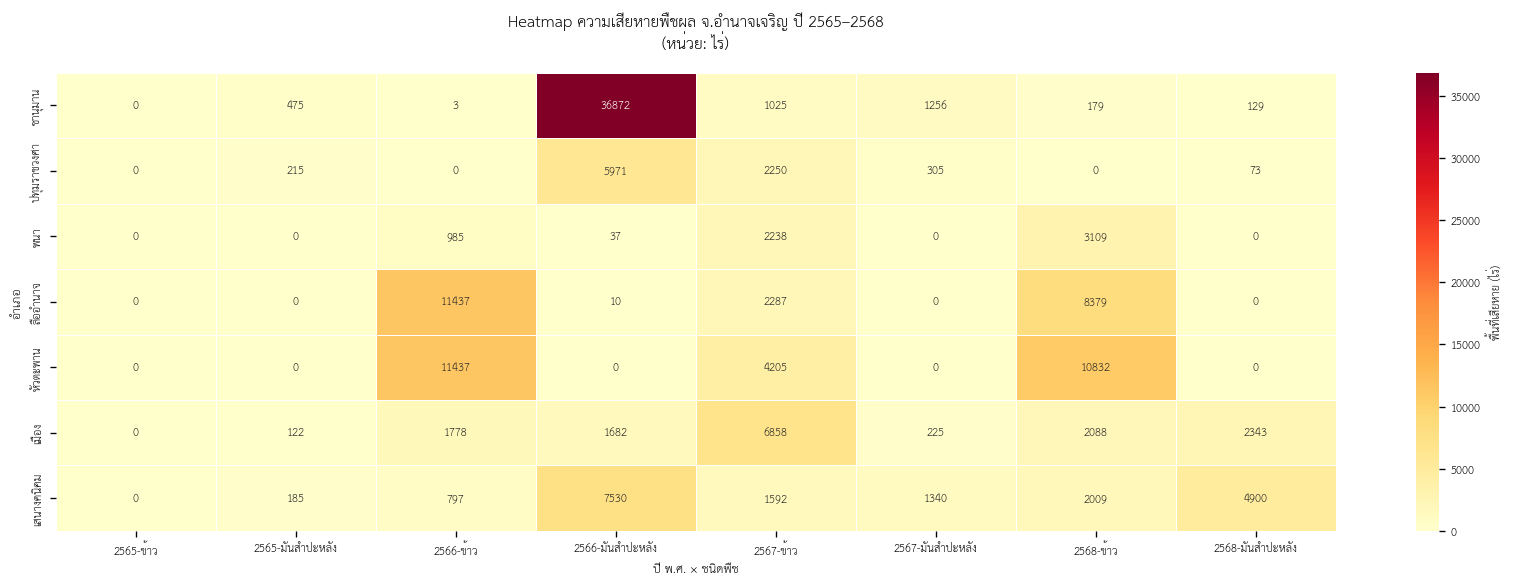

✅ บันทึก: e:\TA_Big_data\กรมส่งเสริมการเกษตร\eda_output\06_amnat_heatmap.png


In [50]:
# ==================================================
# OUTPUT 6B — Heatmap: อำเภอ × ปี × พืช (Static PNG)
# คำถาม RQ-B3: Trend รายปีเป็นอย่างไร?
# ==================================================

# Pivot: อำเภอ เป็น row, (ปี, พืช) เป็น column
pivot_b = df_b.pivot_table(
    index='อำเภอ',
    columns=['ปี', 'ประเภทการปลูก'],
    values='พื้นที่เสียหาย_clean',
    aggfunc='sum',
    fill_value=0
)

fig, ax = plt.subplots(figsize=(14, 5))
sns.heatmap(
    pivot_b,
    annot=True,
    fmt='.0f',
    cmap='YlOrRd',
    linewidths=0.5,
    ax=ax,
    cbar_kws={'label': 'พื้นที่เสียหาย (ไร่)'}
)
ax.set_title(
    'Heatmap ความเสียหายพืชผล จ.อำนาจเจริญ ปี 2565–2568\n(หน่วย: ไร่)',
    fontsize=14, pad=15
)
ax.set_xlabel('ปี พ.ศ. × ชนิดพืช', fontsize=11)
ax.set_ylabel('อำเภอ', fontsize=11)
plt.tight_layout()

out6b = os.path.join(OUT_DIR, '06_amnat_heatmap.png')
plt.savefig(out6b, dpi=150, bbox_inches='tight')
plt.show()
print(f'✅ บันทึก: {out6b}')

---
## Section 6: Case Study 2 — ผลกระทบภาวะฝนทิ้งช่วงต่อเกษตรกร จ.เพชรบูรณ์ 🌧️

### OUTPUT 7 — Grouped Bar + Multi-line Trend

In [51]:
# ==================================================
# OUTPUT 7 — เพชรบูรณ์: พื้นที่เสียหาย + มูลค่าเสียหาย
# คำถาม RQ-A3: อำเภอใดเสียหายมากที่สุด?
# คำถาม RQ-C4: แนวโน้มรายปีเป็นอย่างไร?
# ==================================================

df_cd_clean = df_cd.dropna(subset=['พื้นที่ประสบภัย', 'ปี_พ.ศ.']).copy()
df_cd_clean['ปี_พ.ศ.'] = df_cd_clean['ปี_พ.ศ.'].astype(int).astype(str)

fig7 = make_subplots(
    rows=1, cols=2,
    subplot_titles=[
        'พื้นที่เสียหาย (ไร่) และมูลค่าเสียหาย (บาท) รายอำเภอ',
        'แนวโน้มมูลค่าความเสียหายรายอำเภอ ปี 2565–2568'
    ],
    specs=[[{'secondary_y': True}, {'secondary_y': False}]]
)

# --- ซ้าย: Grouped Bar (พื้นที่เสียหาย) + Line (มูลค่า) ---
colors_year = {'2565': '#3498db', '2566': '#e74c3c', '2568': '#2ecc71'}

for year in df_cd_clean['ปี_พ.ศ.'].unique():
    sub = df_cd_clean[df_cd_clean['ปี_พ.ศ.'] == year]
    fig7.add_trace(
        go.Bar(
            x=sub['พื้นที่ประสบภัย'],
            y=sub['พื้นที่เสียหาย_num'],
            name=f'พื้นที่เสียหาย ปี {year}',
            marker_color=colors_year.get(year, '#95a5a6'),
            opacity=0.75,
            customdata=sub[['มูลค่าเสียหาย_num', 'จำนวนเกษตรกร', 'baht_per_rai']],
            hovertemplate=(
                '<b>%{x}</b> ปี ' + year + '<br>'
                'พื้นที่เสียหาย: %{y:,.1f} ไร่<br>'
                'มูลค่าเสียหาย: %{customdata[0]:,.0f} บาท<br>'
                'เกษตรกร: %{customdata[1]} ราย<br>'
                'บาท/ไร่: %{customdata[2]:,.0f}<extra></extra>'
            )
        ), row=1, col=1, secondary_y=False
    )

# --- ขวา: Multi-line (มูลค่ารายอำเภอ) ---
for amphoe in df_cd_clean['พื้นที่ประสบภัย'].dropna().unique():
    sub = df_cd_clean[df_cd_clean['พื้นที่ประสบภัย'] == amphoe].sort_values('ปี_พ.ศ.')
    if sub['มูลค่าเสียหาย_num'].notna().sum() > 1:
        fig7.add_trace(
            go.Scatter(
                x=sub['ปี_พ.ศ.'],
                y=sub['มูลค่าเสียหาย_num'],
                mode='lines+markers',
                name=amphoe,
                marker=dict(size=8)
            ), row=1, col=2
        )

fig7.update_layout(
    title='ผลกระทบภาวะฝนทิ้งช่วงต่อเกษตรกร จ.เพชรบูรณ์<br>'
          '<sub>Dataset C+D — กรมส่งเสริมการเกษตร</sub>',
    height=500,
    barmode='group',
    plot_bgcolor='white',
    legend=dict(x=1.05, y=1)
)
fig7.update_xaxes(title_text='อำเภอ', row=1, col=1)
fig7.update_yaxes(title_text='พื้นที่เสียหาย (ไร่)', row=1, col=1, secondary_y=False)
fig7.update_xaxes(title_text='ปี พ.ศ.', row=1, col=2)
fig7.update_yaxes(title_text='มูลค่าเสียหาย (บาท)', row=1, col=2)

out7 = os.path.join(OUT_DIR, '07_phetchabun_drought.html')
fig7.write_html(out7)
fig7.show()
print(f'✅ บันทึก: {out7}')

✅ บันทึก: e:\TA_Big_data\กรมส่งเสริมการเกษตร\eda_output\07_phetchabun_drought.html


---
## Section 7: Case Study 3 — ประสิทธิภาพการช่วยเหลืออุทกภัยด้านพืช จ.สุราษฎร์ธานี 🌊

### OUTPUT 8 — Horizontal Bar (เงิน/ไร่) + Mini Folium Map

In [52]:
# ==================================================
# OUTPUT 8A — Horizontal Bar: เงิน/ไร่ รายอำเภอ
# คำถาม RQ-C3: อำเภอใดได้รับงบ/ไร่ สูง/ต่ำกว่าค่าเฉลี่ย?
# ==================================================

df_e_sorted = df_e.sort_values('money_per_rai', ascending=True)
avg_per_rai = df_e['money_per_rai'].mean()

fig8a = go.Figure()

fig8a.add_trace(
    go.Bar(
        x=df_e_sorted['money_per_rai'],
        y=df_e_sorted['อำเภอ'],
        orientation='h',
        marker=dict(
            color=[
                '#27ae60' if v >= avg_per_rai else '#e74c3c'
                for v in df_e_sorted['money_per_rai']
            ]
        ),
        text=[f'{v:,.0f}' for v in df_e_sorted['money_per_rai']],
        textposition='outside',
        customdata=df_e_sorted[['จำนวนเกษตรกร', 'พื้นที่ทางการเกษตร',
                                 'เงิน_num', 'money_per_person']],
        hovertemplate=(
            '<b>อ.%{y}</b><br>'
            'เงิน/ไร่: %{x:,.0f} บาท<br>'
            'เกษตรกร: %{customdata[0]} ราย<br>'
            'พื้นที่: %{customdata[1]} ไร่<br>'
            'วงเงินรวม: %{customdata[2]:,.0f} บาท<br>'
            'เงิน/คน: %{customdata[3]:,.0f} บาท<extra></extra>'
        )
    )
)

# เส้น reference ค่าเฉลี่ย
fig8a.add_vline(
    x=avg_per_rai,
    line_dash='dash',
    line_color='#2c3e50',
    annotation_text=f'ค่าเฉลี่ย: {avg_per_rai:,.0f} บาท/ไร่',
    annotation_position='top right'
)

fig8a.update_layout(
    title='เงินช่วยเหลืออุทกภัยต่อไร่ รายอำเภอ จ.สุราษฎร์ธานี ปี 2568<br>'
          '<sub>🟢 สูงกว่าค่าเฉลี่ย | 🔴 ต่ำกว่าค่าเฉลี่ย | Dataset E — กรมส่งเสริมการเกษตร</sub>',
    xaxis_title='เงินช่วยเหลือต่อไร่ (บาท/ไร่)',
    yaxis_title='อำเภอ',
    height=500,
    plot_bgcolor='white',
    xaxis=dict(gridcolor='#ecf0f1')
)

out8a = os.path.join(OUT_DIR, '08_surat_flood_aid.html')
fig8a.write_html(out8a)
fig8a.show()
print(f'✅ บันทึก: {out8a}')

✅ บันทึก: e:\TA_Big_data\กรมส่งเสริมการเกษตร\eda_output\08_surat_flood_aid.html


In [53]:
# ==================================================
# OUTPUT 8B — Mini Folium Map: อำเภอ สุราษฎร์ธานี
# ขนาด marker ∝ เงิน/ไร่
# ==================================================

df_e_geo = df_e.dropna(subset=['lat', 'lon']).copy()

m8 = folium.Map(
    location=[9.13, 99.33],  # ศูนย์กลาง จ.สุราษฎร์ธานี
    zoom_start=9,
    tiles='CartoDB positron'
)

max_per_rai = df_e_geo['money_per_rai'].max()

for _, row in df_e_geo.iterrows():
    # radius = สัดส่วนกับ เงิน/ไร่ (min 8, max 30)
    radius = 8 + (row['money_per_rai'] / max_per_rai) * 22
    color  = '#27ae60' if row['money_per_rai'] >= avg_per_rai else '#e74c3c'

    popup_html = f"""
    <div style='font-family:Tahoma; width:200px; font-size:13px'>
        <b>อ.{row['อำเภอ']}</b><br>
        💰 เงิน/ไร่: <b>{row['money_per_rai']:,.0f} บาท</b><br>
        💰 เงิน/คน: <b>{row['money_per_person']:,.0f} บาท</b><br>
        🌾 พื้นที่: {row['พื้นที่ทางการเกษตร']} ไร่<br>
        👥 เกษตรกร: {row['จำนวนเกษตรกร']} ราย
    </div>
    """

    folium.CircleMarker(
        location=[row['lat'], row['lon']],
        radius=radius,
        color=color,
        fill=True,
        fill_color=color,
        fill_opacity=0.6,
        popup=folium.Popup(popup_html, max_width=220),
        tooltip=f"อ.{row['อำเภอ']} — {row['money_per_rai']:,.0f} บาท/ไร่"
    ).add_to(m8)

MiniMap(toggle_display=True).add_to(m8)

out8b = os.path.join(OUT_DIR, '08_surat_map.html')
m8.save(out8b)
print(f'✅ บันทึก: {out8b}')
m8

✅ บันทึก: e:\TA_Big_data\กรมส่งเสริมการเกษตร\eda_output\08_surat_map.html


---
## Section 8: สรุปข้อค้นพบ 📝
สรุป Key Findings สำหรับนำเสนอต่อเจ้าหน้าที่หน่วยงานภาครัฐ

In [54]:
# ==================================================
# สรุป Key Findings อัตโนมัติจากข้อมูล
# ==================================================

print('=' * 60)
print('📊 KEY FINDINGS — วิเคราะห์ภัยพิบัติเกษตรและการช่วยเหลือเกษตรกร')
print('    กรมส่งเสริมการเกษตร')
print('=' * 60)

# Finding 1: Top tambon
top_tambon = tambon_agg.sort_values('จำนวนเหตุการณ์', ascending=False).iloc[0]
print(f'\n🔴 Finding 1: Hot Spot ภัยพิบัติ')
print(f'   ตำบลที่ประสบภัยบ่อยที่สุดคือ "{top_tambon["ที่เกิดภัยธรรมชาติ"]}"')
print(f'   ({top_tambon["จำนวนเหตุการณ์"]} เหตุการณ์ | วงเงินรวม {top_tambon["วงเงินรวม"]:,.0f} บาท)')

# Finding 2: Seasonal peak
peak_month = monthly.loc[monthly['จำนวนเหตุการณ์'].idxmax()]
print(f'\n📅 Finding 2: ฤดูกาลภัยพิบัติ')
print(f'   เดือนที่มีภัยพิบัติบ่อยที่สุดคือ เดือน {THAI_MONTH_FULL[int(peak_month["เดือน"])-1]}')
print(f'   ({peak_month["จำนวนเหตุการณ์"]} เหตุการณ์ — วงเงินเฉลี่ย {peak_month["วงเงินเฉลี่ย"]:,.0f} บาท/เหตุการณ์)')

# Finding 3: Coverage
mean_cov = df_a_cov['coverage_rate'].mean()
print(f'\n⚠️  Finding 3: ช่องว่างการช่วยเหลือ')
print(f'   Coverage Rate เฉลี่ยทั่วประเทศ: {mean_cov:.1f}%')
print(f'   Pending cases (รอดำเนินการ): {df_a["is_pending"].sum()} เหตุการณ์')
print(f'   พื้นที่ Coverage < 80%: {len(low_cov)} เหตุการณ์')

# Finding 4: อำนาจเจริญ
worst_year_b = df_b.groupby('ปี')['พื้นที่เสียหาย_clean'].sum().idxmax()
worst_val_b  = df_b.groupby('ปี')['พื้นที่เสียหาย_clean'].sum().max()
print(f'\n🌾 Finding 4: จ.อำนาจเจริญ')
print(f'   ปีที่มีพื้นที่เสียหายมากที่สุด: {worst_year_b} ({worst_val_b:,.0f} ไร่)')

# Finding 5: สุราษฎร์ธานี
best_amphoe  = df_e.loc[df_e['money_per_rai'].idxmax(), 'อำเภอ']
worst_amphoe = df_e.loc[df_e['money_per_rai'].idxmin(), 'อำเภอ']
ratio = df_e['money_per_rai'].max() / df_e['money_per_rai'].min()
print(f'\n🌊 Finding 5: จ.สุราษฎร์ธานี — ความเหลื่อมล้ำของการช่วยเหลือ')
print(f'   เงิน/ไร่ สูงสุด: อ.{best_amphoe} ({df_e["money_per_rai"].max():,.0f} บาท/ไร่)')
print(f'   เงิน/ไร่ ต่ำสุด: อ.{worst_amphoe} ({df_e["money_per_rai"].min():,.0f} บาท/ไร่)')
print(f'   → ต่างกัน {ratio:.1f} เท่า')

print('\n' + '=' * 60)
print('⚠️  ข้อจำกัดของข้อมูล')
print('   - Dataset B–E มีข้อมูลเฉพาะ 1 จังหวัด → เป็น Case Study เท่านั้น')
print('   - Geocoding อาจมีความคลาดเคลื่อนสำหรับชื่อตำบลที่ซ้ำกันหลายจังหวัด')
print('   - Dataset A ไม่มีคอลัมน์ประเภทภัยพิบัติ → ไม่สามารถแยกประเภทภัยได้')
print('=' * 60)

📊 KEY FINDINGS — วิเคราะห์ภัยพิบัติเกษตรและการช่วยเหลือเกษตรกร
    กรมส่งเสริมการเกษตร

🔴 Finding 1: Hot Spot ภัยพิบัติ
   ตำบลที่ประสบภัยบ่อยที่สุดคือ "ต.ควนขนุน"
   (19 เหตุการณ์ | วงเงินรวม 680,456 บาท)

📅 Finding 2: ฤดูกาลภัยพิบัติ
   เดือนที่มีภัยพิบัติบ่อยที่สุดคือ เดือน พ.ย.
   (278 เหตุการณ์ — วงเงินเฉลี่ย 86,255 บาท/เหตุการณ์)

⚠️  Finding 3: ช่องว่างการช่วยเหลือ
   Coverage Rate เฉลี่ยทั่วประเทศ: 100.0%
   Pending cases (รอดำเนินการ): 0 เหตุการณ์
   พื้นที่ Coverage < 80%: 0 เหตุการณ์

🌾 Finding 4: จ.อำนาจเจริญ
   ปีที่มีพื้นที่เสียหายมากที่สุด: 2566 (78,539 ไร่)

🌊 Finding 5: จ.สุราษฎร์ธานี — ความเหลื่อมล้ำของการช่วยเหลือ
   เงิน/ไร่ สูงสุด: อ.คีรีรัฐนิคม (4,048 บาท/ไร่)
   เงิน/ไร่ ต่ำสุด: อ.ดอนสัก (2,120 บาท/ไร่)
   → ต่างกัน 1.9 เท่า

⚠️  ข้อจำกัดของข้อมูล
   - Dataset B–E มีข้อมูลเฉพาะ 1 จังหวัด → เป็น Case Study เท่านั้น
   - Geocoding อาจมีความคลาดเคลื่อนสำหรับชื่อตำบลที่ซ้ำกันหลายจังหวัด
   - Dataset A ไม่มีคอลัมน์ประเภทภัยพิบัติ → ไม่สามารถแยกประเภทภัยได้


In [55]:
# ==================================================
# สรุปไฟล์ Output ทั้งหมด
# ==================================================

output_files = [
    ('01_disaster_map.html',       'Interactive Marker Map — ภัยพิบัติทั่วประเทศ'),
    ('02_choropleth_money.html',   'Choropleth — วงเงินรวมรายตำบล (ต้องใช้ GeoJSON)'),
    ('03_seasonal_pattern.html',   'Seasonal Pattern — ภัยพิบัติรายเดือน'),
    ('03_seasonal_pattern.png',    'Seasonal Pattern — Static PNG'),
    ('04_money_distribution.html', 'Distribution — วงเงินช่วยเหลือ'),
    ('05_coverage_gap.html',       'Gap Analysis — Coverage Rate + Pending Cases'),
    ('06_amnat_crop_damage.html',  'Case Study อำนาจเจริญ — Animated Bar'),
    ('06_amnat_heatmap.png',       'Case Study อำนาจเจริญ — Heatmap PNG'),
    ('07_phetchabun_drought.html', 'Case Study เพชรบูรณ์ — ฝนทิ้งช่วง'),
    ('08_surat_flood_aid.html',    'Case Study สุราษฎร์ธานี — เงิน/ไร่ Bar'),
    ('08_surat_map.html',          'Case Study สุราษฎร์ธานี — Folium Map'),
]

print('📦 Output Files:')
print(f'{"#":>3}  {"ไฟล์":<40} {"คำอธิบาย"}')
print('-' * 80)
for i, (fname, desc) in enumerate(output_files, 1):
    path   = os.path.join(OUT_DIR, fname)
    exists = '✅' if os.path.exists(path) else '❌'
    print(f'{i:>3}  {fname:<40} {exists} {desc}')

📦 Output Files:
  #  ไฟล์                                     คำอธิบาย
--------------------------------------------------------------------------------
  1  01_disaster_map.html                     ✅ Interactive Marker Map — ภัยพิบัติทั่วประเทศ
  2  02_choropleth_money.html                 ✅ Choropleth — วงเงินรวมรายตำบล (ต้องใช้ GeoJSON)
  3  03_seasonal_pattern.html                 ✅ Seasonal Pattern — ภัยพิบัติรายเดือน
  4  03_seasonal_pattern.png                  ✅ Seasonal Pattern — Static PNG
  5  04_money_distribution.html               ✅ Distribution — วงเงินช่วยเหลือ
  6  05_coverage_gap.html                     ✅ Gap Analysis — Coverage Rate + Pending Cases
  7  06_amnat_crop_damage.html                ✅ Case Study อำนาจเจริญ — Animated Bar
  8  06_amnat_heatmap.png                     ✅ Case Study อำนาจเจริญ — Heatmap PNG
  9  07_phetchabun_drought.html               ✅ Case Study เพชรบูรณ์ — ฝนทิ้งช่วง
 10  08_surat_flood_aid.html                  ✅ Case Study สุราษฎร์ธานี —